# Fresnel/Debye Donut Benchmark: Annular Paraboloid (v1)

**Author:** Aaron Roodman (with Claude)
**Date Created:** 2026-09-30
**Last Modified:** 2026-09-30
**Status:** Complete
**Keywords:** Fresnel, Debye, Huygens, diffraction, donut, batoid, fftPSF, huygensPSF, NUFFT, HCIPy

## Description

Validation of diffraction models for a defocused star image (a "donut") against a
semi-analytic reference. The test optic is an on-axis annular paraboloid with Rubin's
focal ratio (f/1.234), diameter (8.36 m) and central obscuration (0.612, dimensionless
ratio of inner to outer clear-aperture diameter), with the detector 1.5 mm from focus.
On axis a paraboloid is stigmatic, so the beam is a perfect spherical wave and the
diffraction integral reduces to one dimension.

Models compared:
1. **Scalar Debye integral** (non-paraxial, semi-analytic): the reference.
2. **Paraxial Fresnel (Lommel) integral**, and the same donut from **HCIPy**, an
   independent open-source code. This is what any paraxial Fresnel or
   Fraunhofer-with-defocus code (HCIPy, POPPY, PROPER, prysm, GalSim) computes here.
3. **Geometric optics**: analytic irradiance, and a batoid random-ray histogram.
4. **batoid `fftPSF`**: FFT of the traced exit-pupil wavefront.
5. **batoid Huygens sum** (`huygensPSF` algorithm), evaluated with a non-uniform FFT
   (FINUFFT), both with batoid's unit ray weights and with the energy-conserving
   Debye-Wolf weight sqrt(dOmega/d^2u) per ray.

**Output:** figures in `optics/output/fresnel/`.

**Based on:** `optics/docs/studies/fresnel_donuts.md`; batoid `analysis.huygensPSF`
and `analysis.fftPSF` (v0.8.1).

## Change Log

| Date | Author | Description |
|------|--------|-------------|
| 2026-09-30 | Aaron Roodman (with Claude) | Initial version |

## Table of Contents

1. [Parameters](#params)
2. [Setup & Imports](#setup)
3. [Helper Functions](#functions)
4. [Scales of the problem](#scales)
5. [Semi-analytic references](#analytic)
6. [batoid Huygens sum = NUFFT](#huygens)
7. [All models: images and radial profiles](#models)
8. [Summary metrics](#summary)
9. [Pixel-level comparison (10 µm pixels)](#pixels)
10. [Conclusions](#conclusions)

<a id='params'></a>
## Parameters

In [1]:
# ============================================================
# Parameters — All configurable values collected here
# ============================================================
wavelength = 622e-9        # m, r band
focal_length = 10.31       # m, Rubin effective focal length
diameter = 8.36            # m, outer clear-aperture diameter
obscuration = 0.612        # dimensionless, inner/outer diameter ratio
defocus = 1.5e-3           # m, detector distance beyond focus

nx_pupil = 2560            # rays across the entrance-pupil grid
dx_image = 0.5e-6          # m, Huygens/NUFFT image sample spacing
npix_image = 3200          # image samples per side (1.6 mm field)
n_geometric_rays = 20_000_000  # random rays for the geometric histogram

r_step_analytic = 0.1e-6   # m, radial sampling of the semi-analytic integrals
annulus_width = 2e-6       # m, radial-profile annulus width
pixel_size = 10e-6         # m, LSSTCam pixel
npix_pixel = 160           # pixels per side of the pixel-level images

output_date = '20260930'

<a id='setup'></a>
## Setup & Imports

In [2]:
import sys
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, str(next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'common').is_dir())))
from common.utils import setup_plotting, repo_root

root = repo_root()
sys.path.insert(0, str(root / 'optics' / 'code' / 'fresnel'))
import fresnel_donut as fd     # imports finufft before batoid (OpenMP order)
import batoid
import hcipy

setup_plotting()
output_dir = root / 'optics' / 'output' / 'fresnel'
output_dir.mkdir(parents=True, exist_ok=True)
print('batoid', batoid.__version__, '| hcipy', hcipy.__version__)

batoid 0.8.1 | hcipy 0.7.1


<a id='functions'></a>
## Helper Functions

In [3]:
r_edges = np.arange(0, 0.8e-3 + 1e-12, annulus_width)
r_centers = 0.5 * (r_edges[1:] + r_edges[:-1])
annulus_area = np.pi * np.diff(r_edges**2)


def bin_analytic(r, E):
    # Area-weighted mean of a finely sampled radial profile in each annulus,
    # renormalised to unit flux over the annuli (1/m^2).
    idx = np.digitize(r, r_edges) - 1
    ok = (idx >= 0) & (idx < len(r_centers))
    num = np.bincount(idx[ok], (E * r)[ok], len(r_centers))
    den = np.bincount(idx[ok], r[ok], len(r_centers))
    out = num / den
    return out / np.sum(out * annulus_area)


def grid_profile(img, xs, ys, center=(0.0, 0.0)):
    X, Y = np.meshgrid(xs, ys)
    return fd.radial_profile(X.ravel(), Y.ravel(), img.ravel(), center, r_edges)


def enclosed_radii(profile, fractions=(0.02, 0.5, 0.98)):
    # Radii (m) enclosing the given fractions of total flux.
    cum = np.cumsum(profile * annulus_area)
    return np.interp(fractions, cum / cum[-1], r_edges[1:])


def inner_outer_ratio(profile, r_in, r_out, width=40e-6):
    # Mean irradiance in a band just inside the inner edge over the same just
    # inside the outer edge (dimensionless).
    a = profile[(r_centers > r_in + 15e-6) & (r_centers < r_in + 15e-6 + width)]
    b = profile[(r_centers < r_out - 15e-6) & (r_centers > r_out - 15e-6 - width)]
    return a.mean() / b.mean()

<a id='scales'></a>
## 1. Scales of the problem

The defocus is large, about 200 waves of peak-to-valley wavefront error for Rubin's
beam, and the Fresnel number of the defocused beam is several hundred, so the
geometric shadow is sharp and diffraction lives in a ~√(λΔz) band at each edge. At
f/1.234 the paraxial approximation is poor: the exact ray angle is
tan(θ/2) = h/2f for a paraboloid, so the geometric donut edge is at
Δz·tan θ, not the paraxial Δz·h/f.

The ray grid must sample the pupil finely enough that adjacent rays differ by less
than π in phase at the donut edge. Equivalently, the image-plane alias period
λ f / Δu must exceed the donut diameter.

In [4]:
(r_in, r_out), (r_in_par, r_out_par) = fd.parabola_donut_radii(
    focal_length, diameter, obscuration, defocus)
N = focal_length / diameter
pv_defocus_waves = defocus / (8 * N**2) / wavelength
fresnel_number = r_out**2 / (wavelength * defocus)
edge_scale = np.sqrt(wavelength * defocus)
du = diameter / (nx_pupil - 2)
alias_period = wavelength * focal_length / du

print(f'focal ratio N = {N:.4f} (dimensionless, focal length / diameter)')
print(f'geometric donut radii, exact:    inner {r_in*1e6:.1f} um, outer {r_out*1e6:.1f} um')
print(f'geometric donut radii, paraxial: inner {r_in_par*1e6:.1f} um, outer {r_out_par*1e6:.1f} um')
print(f'outer radius paraxial/exact = {r_out_par/r_out:.4f} (dimensionless)')
print(f'paraxial defocus W020 = {pv_defocus_waves:.0f} waves at {wavelength*1e9:.0f} nm')
print(f'Fresnel number r_out^2/(lambda dz) = {fresnel_number:.0f} (dimensionless)')
print(f'edge diffraction scale sqrt(lambda dz) = {edge_scale*1e6:.1f} um')
print(f'pupil grid spacing {du*1e3:.2f} mm -> image alias period {alias_period*1e3:.2f} mm '
      f'(donut diameter {2*r_out*1e3:.2f} mm)')

focal ratio N = 1.2333 (dimensionless, focal length / diameter)
geometric donut radii, exact:    inner 378.0 um, outer 634.2 um
geometric donut radii, paraxial: inner 372.2 um, outer 608.1 um
outer radius paraxial/exact = 0.9589 (dimensionless)
paraxial defocus W020 = 198 waves at 622 nm
Fresnel number r_out^2/(lambda dz) = 431 (dimensionless)
edge diffraction scale sqrt(lambda dz) = 30.5 um
pupil grid spacing 3.27 mm -> image alias period 1.96 mm (donut diameter 1.27 mm)


<a id='analytic'></a>
## 2. Semi-analytic references

With pupil height h, ray angle θ(h) and uniform power per unit entrance-pupil area,
the scalar Debye field and its z-derivative on the detector plane are

$$U(r) = \int w(h)\, e^{ik\Delta z\cos\theta}\, J_0(kr\sin\theta)\, h\,dh, \qquad
V(r) = \int w(h)\cos\theta\, e^{ik\Delta z\cos\theta}\, J_0(kr\sin\theta)\, h\,dh,$$

with $w = \sqrt{d\Omega/d^2u} = \cos^2(\theta/2)/f$, and the irradiance (scalar energy
flux through the detector plane) is $E = \mathrm{Re}(U^* V)$. The paraxial Fresnel
(Lommel) version replaces $\cos\theta \to 1 - h^2/2f^2$, $\sin\theta \to h/f$, $w \to 1$.
The integrals use composite Gauss-Legendre quadrature; doubling the number of panels
changes the Debye profile by less than 1e-12 of its peak (checked below).

For a perfect system the intensity is symmetric in ±Δz (the two fields are complex
conjugates), which is also checked.

In [5]:
r_fine = np.arange(r_step_analytic / 2, 0.8e-3, r_step_analytic)
t0 = time.perf_counter()
E_debye = fd.parabola_debye_profile(r_fine, wavelength, focal_length, diameter,
                                    obscuration, defocus)
print(f'Debye integral: {time.perf_counter()-t0:.1f} s for {len(r_fine)} radii')
E_debye_2x = fd.parabola_debye_profile(r_fine, wavelength, focal_length, diameter,
                                       obscuration, defocus, n_panels=3000)
E_debye_intra = fd.parabola_debye_profile(r_fine, wavelength, focal_length, diameter,
                                          obscuration, -defocus)
E_paraxial = fd.parabola_paraxial_profile(r_fine, wavelength, focal_length, diameter,
                                          obscuration, defocus)
E_geo = fd.parabola_geometric_profile(r_fine, focal_length, diameter, obscuration,
                                      defocus)
peak = E_debye.max()
print(f'quadrature convergence: max|E(2x panels) - E| / peak = '
      f'{np.max(np.abs(E_debye_2x - E_debye))/peak:.1e} (dimensionless)')
print(f'intra/extra symmetry:   max|E(-dz) - E(+dz)| / peak = '
      f'{np.max(np.abs(E_debye_intra - E_debye))/peak:.1e} (dimensionless)')

prof_debye = bin_analytic(r_fine, E_debye)
prof_paraxial = bin_analytic(r_fine, E_paraxial)
prof_geo_analytic = bin_analytic(r_fine, E_geo)

Debye integral: 5.6 s for 8000 radii


quadrature convergence: max|E(2x panels) - E| / peak = 1.8e-13 (dimensionless)
intra/extra symmetry:   max|E(-dz) - E(+dz)| / peak = 0.0e+00 (dimensionless)


### Independent paraxial check with HCIPy

HCIPy propagates an annular pupil with the paraxial defocus phase
exp(−ikΔz h²/2f²) to the focal plane with a matrix Fourier transform
(`FraunhoferPropagator`). Mathematically this is the paraxial Fresnel integral, so it
must reproduce the Lommel curve; it confirms the quadrature and the normalisation
independently of batoid and of this module.

In [6]:
k = 2 * np.pi / wavelength
t0 = time.perf_counter()
pupil_grid = hcipy.make_pupil_grid(2048, diameter)
aperture = hcipy.evaluate_supersampled(
    hcipy.make_obstructed_circular_aperture(diameter, obscuration), pupil_grid, 8)
rho2 = pupil_grid.x**2 + pupil_grid.y**2
wf = hcipy.Wavefront(aperture * np.exp(-1j * k * defocus * rho2 / (2 * focal_length**2)),
                     wavelength)
focal_grid = hcipy.make_pupil_grid(npix_image, npix_image * dx_image)
prop = hcipy.FraunhoferPropagator(pupil_grid, focal_grid, focal_length=focal_length)
img_hcipy = np.asarray(prop(wf).power)
print(f'HCIPy: {time.perf_counter()-t0:.1f} s')
prof_hcipy = fd.radial_profile(np.asarray(focal_grid.x), np.asarray(focal_grid.y),
                               img_hcipy, (0, 0), r_edges)
d = prof_hcipy - prof_paraxial
print(f'HCIPy vs Lommel: rms {np.sqrt(np.mean(d**2))/prof_paraxial.max():.2e}, '
      f'max {np.max(np.abs(d))/prof_paraxial.max():.2e} (fraction of peak irradiance)')

HCIPy: 1.0 s


HCIPy vs Lommel: rms 2.35e-03, max 3.91e-02 (fraction of peak irradiance)


<a id='huygens'></a>
## 3. batoid's Huygens sum is a non-uniform FFT

`batoid.analysis.huygensPSF` evaluates, for every output pixel in a Python loop,

$$U(\mathbf{x}) = \sum_j f_j \exp\{i[\mathbf{k}_j\cdot(\mathbf{x}-\mathbf{r}_j) + k_0 t_j]\}$$

over traced rays j with detector positions $\mathbf{r}_j$, wave vectors $\mathbf{k}_j$ and
optical path $t_j$ (`RayVector.sumAmplitude`; the per-ray factor $f_j$ is the ray
`flux`, 1 by default). On a uniform output lattice this is exactly a type-1 non-uniform
FFT with non-uniform points $\mathbf{k}_j\,dx$. Below: (a) the NUFFT reproduces
batoid's own sum, point by point, (b) batoid's own `huygensPSF` on a small lattice,
and (c) the cost of each.

The Debye-Wolf weight per ray, $w_j=\sqrt{d\Omega/d^2u}$, comes from finite
differences of the ray direction cosines over the pupil grid. For the paraboloid the
analytic value is $\cos^2(\theta/2)/f$.

In [7]:
optic = fd.make_parabola(focal_length, diameter, obscuration, defocus)
t0 = time.perf_counter()
rays = fd.trace_pupil_grid(optic, wavelength, nx_pupil)
good = ~rays.vignetted
print(f'traced {len(rays)} rays, {good.sum()} unvignetted, in {time.perf_counter()-t0:.1f} s')
weights, gamma = fd.debye_weights(rays, nx_pupil)

# Weight check against the analytic cos^2(theta/2)
h = np.hypot(*fd.batoid.RayVector.asGrid(
    optic=optic, wavelength=wavelength, dirCos=fd.dircos(0, 0), nx=nx_pupil).r[:, :2].T)
theta = 2 * np.arctan(h / (2 * focal_length))
w_true = np.cos(theta / 2)**2
w_true /= w_true[good].mean()
print(f'Debye weights: range {weights[good].min():.4f} to {weights[good].max():.4f} '
      f'(dimensionless, mean 1); max |finite-difference - analytic| = '
      f'{np.max(np.abs(weights - w_true)[good]):.1e}')

# (a) point-by-point check against batoid's sumAmplitude
rng = np.random.default_rng(2)
pts = rng.uniform(-0.7e-3, 0.7e-3, (40, 2))
amp_batoid, sec_per_point = fd.batoid_sum_amplitude(rays, pts)
amp_nufft = fd.nufft_amplitude_at(rays, wavelength, pts)
print(f'NUFFT vs batoid sumAmplitude: max |dA|/max|A| = '
      f'{np.max(np.abs(amp_nufft - amp_batoid))/np.max(np.abs(amp_batoid)):.1e} '
      f'(dimensionless, {len(pts)} points)')
print(f'batoid sumAmplitude: {sec_per_point*1e3:.1f} ms per output point with '
      f'{good.sum()} rays')

traced 6553600 rays, 3214092 unvignetted, in 0.2 s
Debye weights: range 0.9876 to 1.0126 (dimensionless, mean 1); max |finite-difference - analytic| = 1.2e-09


/Users/roodman/Library/Python/3.13/lib/python/site-packages/finufft/_interfaces.py:427: UserWarning: Argument `s` does not satisfy the following requirement: C. Copying array (this may reduce performance)
  warnings.warn(f"Argument `{name}` does not satisfy the following requirement: {prop}. Copying array (this may reduce performance)")
/Users/roodman/Library/Python/3.13/lib/python/site-packages/finufft/_interfaces.py:427: UserWarning: Argument `t` does not satisfy the following requirement: C. Copying array (this may reduce performance)
  warnings.warn(f"Argument `{name}` does not satisfy the following requirement: {prop}. Copying array (this may reduce performance)")


NUFFT vs batoid sumAmplitude: max |dA|/max|A| = 2.6e-12 (dimensionless, 40 points)
batoid sumAmplitude: 36.4 ms per output point with 3214092 rays


In [8]:
# (b) batoid's own huygensPSF on a small lattice, versus the NUFFT at the same points
nx_small, nout_small, dx_small = 512, 16, 20e-6
t0 = time.perf_counter()
hpsf = batoid.analysis.huygensPSF(optic, 0.0, 0.0, wavelength, nx=nx_small,
                                  dx=dx_small, nxOut=nout_small)
t_huygens = time.perf_counter() - t0
rays_small = fd.trace_pupil_grid(optic, wavelength, nx_small)
xy = np.stack([hpsf.coords[..., 0].T.ravel(), hpsf.coords[..., 1].T.ravel()], axis=1)
I_nufft = np.abs(fd.nufft_amplitude_at(rays_small, wavelength, xy))**2
I_batoid = hpsf.array.ravel()
print(f'batoid huygensPSF {nout_small}x{nout_small} points, {nx_small}^2 ray grid: '
      f'{t_huygens:.1f} s')
print(f'max |I_nufft - I_huygensPSF| / max I = '
      f'{np.max(np.abs(I_nufft - I_batoid))/I_batoid.max():.1e} (dimensionless)')

# (c) cost of the full image both ways
t0 = time.perf_counter()
img_unweighted, xs, ys = fd.huygens_image(rays, wavelength, (0, 0), dx_image, npix_image)
t_nufft = time.perf_counter() - t0
img_weighted, _, _ = fd.huygens_image(rays, wavelength, (0, 0), dx_image, npix_image,
                                      weights=weights, gamma=gamma)
n_points = npix_image**2
print(f'NUFFT image {npix_image}x{npix_image} samples at {dx_image*1e6:.2f} um: '
      f'{t_nufft:.1f} s')
print(f'batoid huygensPSF for the same image (extrapolated): '
      f'{n_points*sec_per_point/3600:.0f} h, i.e. {n_points*sec_per_point/t_nufft:.1e} '
      f'times slower (dimensionless ratio of wall-clock times)')

/Users/roodman/Library/Python/3.13/lib/python/site-packages/finufft/_interfaces.py:427: UserWarning: Argument `s` does not satisfy the following requirement: C. Copying array (this may reduce performance)
  warnings.warn(f"Argument `{name}` does not satisfy the following requirement: {prop}. Copying array (this may reduce performance)")
/Users/roodman/Library/Python/3.13/lib/python/site-packages/finufft/_interfaces.py:427: UserWarning: Argument `t` does not satisfy the following requirement: C. Copying array (this may reduce performance)
  warnings.warn(f"Argument `{name}` does not satisfy the following requirement: {prop}. Copying array (this may reduce performance)")


batoid huygensPSF 16x16 points, 512^2 ray grid: 0.4 s
max |I_nufft - I_huygensPSF| / max I = 9.5e-13 (dimensionless)


NUFFT image 3200x3200 samples at 0.50 um: 0.3 s
batoid huygensPSF for the same image (extrapolated): 103 h, i.e. 1.2e+06 times slower (dimensionless ratio of wall-clock times)


<a id='models'></a>
## 4. All models: images and radial profiles

The remaining models: batoid `fftPSF` on the same 2560² pupil grid (no padding;
its lattice spacing is λN), and a geometric image from 2×10⁷ random rays.

In [9]:
t0 = time.perf_counter()
x_fft, y_fft, v_fft, fft_spacing = fd.fftpsf_samples(optic, wavelength, nx_pupil, 1)
print(f'fftPSF: {time.perf_counter()-t0:.1f} s, lattice spacing {fft_spacing*1e6:.3f} um')
prof_fft = fd.radial_profile(x_fft, y_fft, v_fft, (0, 0), r_edges)

t0 = time.perf_counter()
xg, yg = fd.geometric_positions(optic, wavelength, n_geometric_rays)
print(f'geometric: {len(xg)} rays on the detector in {time.perf_counter()-t0:.1f} s')
prof_geo_rays = fd.radial_profile(xg, yg, None, (0, 0), r_edges)

prof_weighted = grid_profile(img_weighted, xs, ys)
prof_unweighted = grid_profile(img_unweighted, xs, ys)

fftPSF: 0.7 s, lattice spacing 0.788 um


geometric: 9823434 rays on the detector in 1.0 s


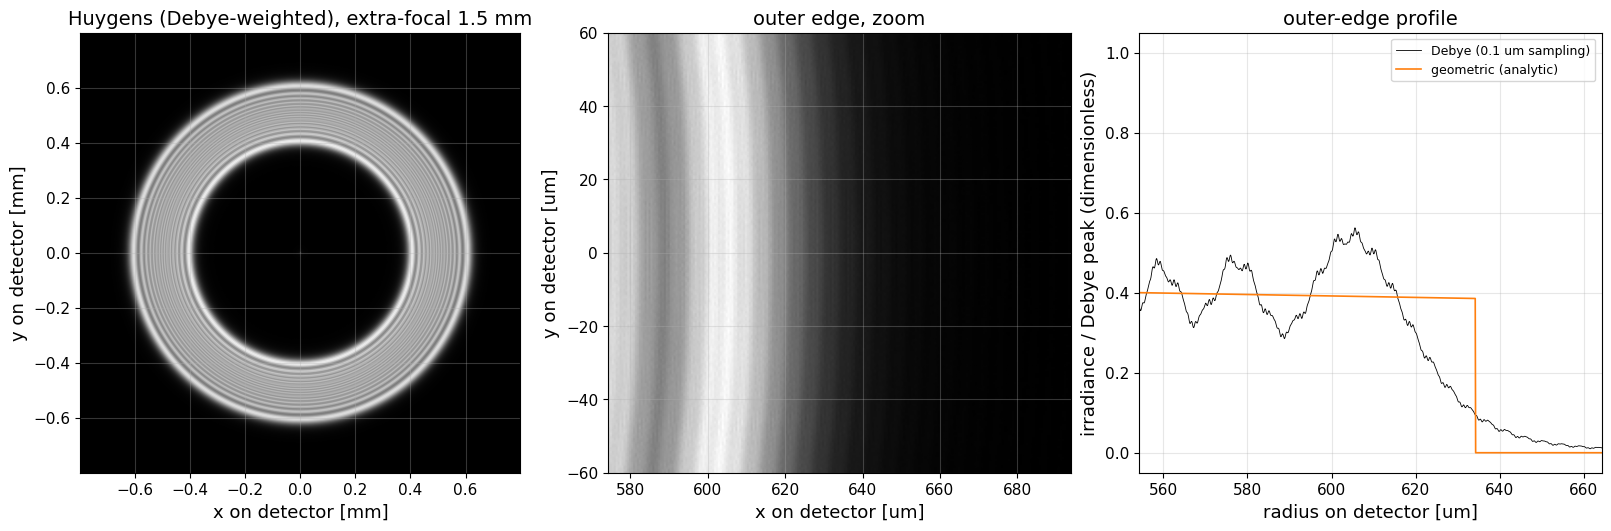

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.2))
ext = np.array([xs[0], xs[-1], ys[0], ys[-1]]) * 1e3
axes[0].imshow(img_weighted, origin='lower', extent=ext, cmap='gray')
axes[0].set_title('Huygens (Debye-weighted), extra-focal 1.5 mm')
axes[0].set_xlabel('x on detector [mm]'); axes[0].set_ylabel('y on detector [mm]')
zoom = (np.abs(xs - r_out) < 60e-6)
iy = np.argmin(np.abs(ys))
sl = img_weighted[iy - 120:iy + 120][:, zoom]
axes[1].imshow(sl, origin='lower', aspect='auto', cmap='gray',
               extent=[xs[zoom][0]*1e6, xs[zoom][-1]*1e6, -60, 60])
axes[1].set_title('outer edge, zoom')
axes[1].set_xlabel('x on detector [um]'); axes[1].set_ylabel('y on detector [um]')
um = r_fine * 1e6
axes[2].plot(um, E_debye / peak, 'k', lw=0.6, label='Debye (0.1 um sampling)')
axes[2].plot(um, E_geo / peak, 'C1', lw=1.2, label='geometric (analytic)')
axes[2].set_xlim(r_out * 1e6 - 80, r_out * 1e6 + 30)
axes[2].set_xlabel('radius on detector [um]')
axes[2].set_ylabel('irradiance / Debye peak (dimensionless)')
axes[2].set_title('outer-edge profile')
axes[2].legend(fontsize=9)
fig.savefig(output_dir / f'optics_fresnel_parabola_image_{output_date}.png', dpi=120)

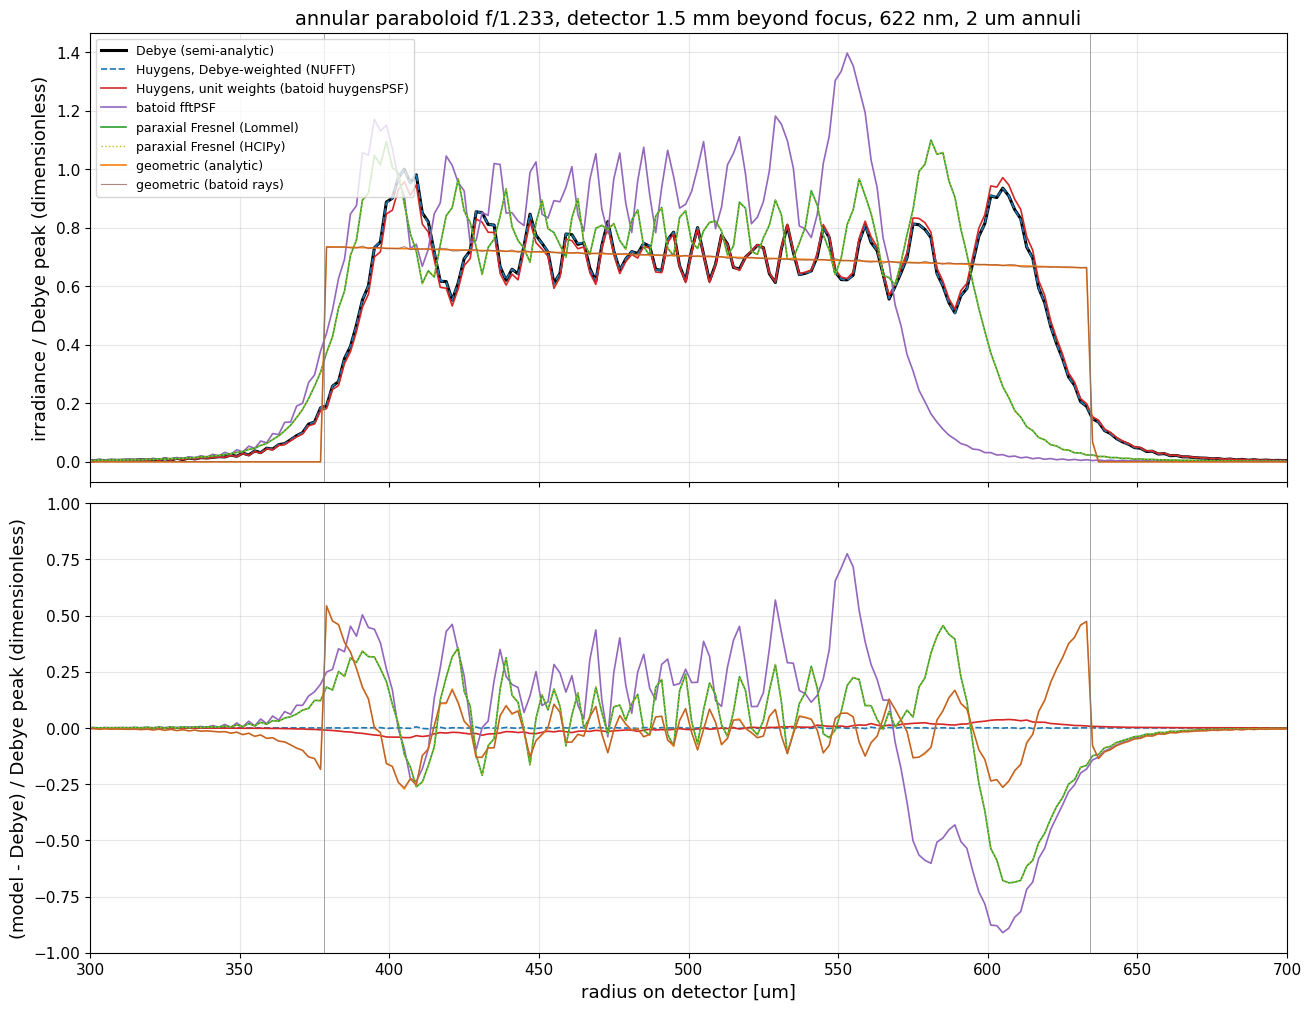

In [11]:
models = {
    'Debye (semi-analytic)': (prof_debye, dict(color='k', lw=2.2)),
    'Huygens, Debye-weighted (NUFFT)': (prof_weighted, dict(color='C0', lw=1.2, ls='--')),
    'Huygens, unit weights (batoid huygensPSF)': (prof_unweighted, dict(color='C3', lw=1.2)),
    'batoid fftPSF': (prof_fft, dict(color='C4', lw=1.2)),
    'paraxial Fresnel (Lommel)': (prof_paraxial, dict(color='C2', lw=1.2)),
    'paraxial Fresnel (HCIPy)': (prof_hcipy, dict(color='C8', lw=1.0, ls=':')),
    'geometric (analytic)': (prof_geo_analytic, dict(color='C1', lw=1.2)),
    'geometric (batoid rays)': (prof_geo_rays, dict(color='C5', lw=0.8, alpha=0.7)),
}
fig, axes = plt.subplots(2, 1, figsize=(13, 10), sharex=True)
for name, (p, kw) in models.items():
    axes[0].plot(r_centers * 1e6, p / prof_debye.max(), label=name, **kw)
    if name != 'Debye (semi-analytic)':
        axes[1].plot(r_centers * 1e6, (p - prof_debye) / prof_debye.max(), **kw)
for a in axes:
    a.axvline(r_in * 1e6, color='gray', lw=0.5)
    a.axvline(r_out * 1e6, color='gray', lw=0.5)
axes[0].set_ylabel('irradiance / Debye peak (dimensionless)')
axes[0].legend(fontsize=9, loc='upper left')
axes[0].set_title(f'annular paraboloid f/{N:.3f}, detector {defocus*1e3:.1f} mm beyond focus, '
                  f'{wavelength*1e9:.0f} nm, {annulus_width*1e6:.0f} um annuli')
axes[1].set_ylabel('(model - Debye) / Debye peak (dimensionless)')
axes[1].set_xlabel('radius on detector [um]')
axes[1].set_xlim(300, 700)
axes[1].set_ylim(-1.0, 1.0)
fig.savefig(output_dir / f'optics_fresnel_parabola_profiles_{output_date}.png', dpi=120)

<a id='summary'></a>
## 5. Summary metrics

For each model: the radii enclosing 2%, 50% and 98% of the flux; the inner-to-outer
irradiance ratio (mean irradiance in a 40 µm band starting 15 µm inside the inner
edge, divided by the same inside the outer edge); and the RMS and maximum of
(model − Debye) over the profile, as fractions of the Debye peak irradiance.

In [12]:
rows = []
for name, (p, _) in models.items():
    r02, r50, r98 = enclosed_radii(p)
    d = p - prof_debye
    rows.append((name, r02 * 1e6, r50 * 1e6, r98 * 1e6,
                 inner_outer_ratio(p, r_in, r_out),
                 np.sqrt(np.mean(d**2)) / prof_debye.max(),
                 np.max(np.abs(d)) / prof_debye.max()))
hdr = (f"{'model':44s} {'r02 [um]':>9s} {'r50 [um]':>9s} {'r98 [um]':>9s} "
       f"{'in/out [-]':>10s} {'rms [pk]':>9s} {'max [pk]':>9s}")
print(hdr); print('-' * len(hdr))
for row in rows:
    print(f'{row[0]:44s} {row[1]:9.2f} {row[2]:9.2f} {row[3]:9.2f} {row[4]:10.4f} '
          f'{row[5]:9.4f} {row[6]:9.4f}')

model                                         r02 [um]  r50 [um]  r98 [um] in/out [-]  rms [pk]  max [pk]
---------------------------------------------------------------------------------------------------------
Debye (semi-analytic)                           385.57    518.64    632.09     1.1032    0.0000    0.0000
Huygens, Debye-weighted (NUFFT)                 385.56    518.64    632.13     1.1034    0.0010    0.0048
Huygens, unit weights (batoid huygensPSF)       386.17    521.72    632.82     1.0230    0.0114    0.0431
batoid fftPSF                                   377.51    490.15    576.86    18.2332    0.2248    0.9107
paraxial Fresnel (Lommel)                       379.41    504.04    606.43     1.6568    0.1425    0.6891
paraxial Fresnel (HCIPy)                        379.50    504.08    606.51     1.6573    0.1424    0.6889
geometric (analytic)                            384.46    518.81    629.88     1.0790    0.0931    0.5437
geometric (batoid rays)                       

<a id='pixels'></a>
## 6. Pixel-level comparison (10 µm pixels)

What matters for donut wavefront fitting is the image integrated over 10 µm pixels.
Each model is binned to a 160 × 160 pixel image centred on the chief ray and
normalised to unit total flux; the residual against the Debye-weighted Huygens image
(validated above against the semi-analytic Debye integral) is shown as a fraction of
the reference's peak pixel.

model                         rms resid [pk]  sum|resid| [flux]
Huygens, Debye-weighted               0.0000             0.0000
Huygens, unit weights                 0.0192             0.0252
fftPSF                                0.3911             0.5102
geometric rays                        0.1285             0.1425
rms over pixels with reference > 5% of peak, as a fraction of the reference peak pixel; sum|resid| is the total absolute flux moved, as a fraction of total flux


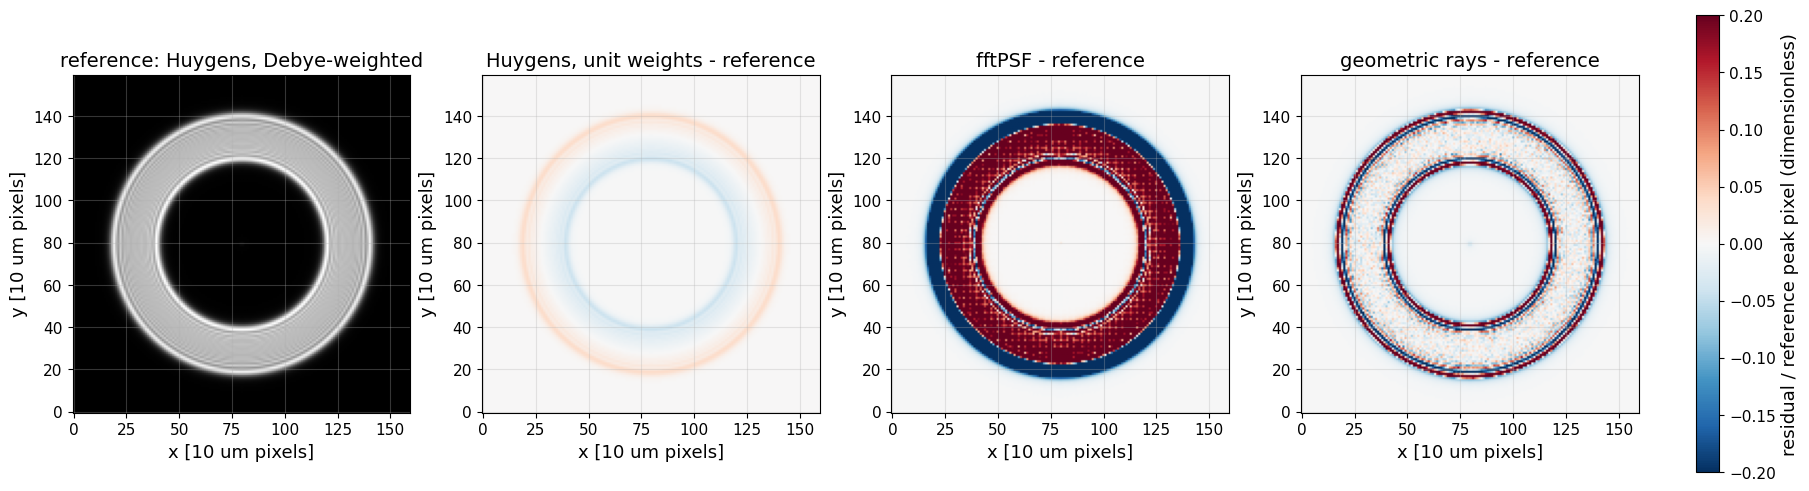

In [13]:
Xs, Ys = np.meshgrid(xs, ys)
pix = {
    'Huygens, Debye-weighted': fd.bin_to_pixels(Xs.ravel(), Ys.ravel(), img_weighted.ravel(),
                                                (0, 0), pixel_size, npix_pixel),
    'Huygens, unit weights': fd.bin_to_pixels(Xs.ravel(), Ys.ravel(), img_unweighted.ravel(),
                                              (0, 0), pixel_size, npix_pixel),
    'fftPSF': fd.bin_to_pixels(x_fft, y_fft, v_fft, (0, 0), pixel_size, npix_pixel),
    'geometric rays': fd.bin_to_pixels(xg, yg, None, (0, 0), pixel_size, npix_pixel),
}
ref = pix['Huygens, Debye-weighted']
fig, axes = plt.subplots(1, 4, figsize=(18, 4.8))
axes[0].imshow(ref, origin='lower', cmap='gray')
axes[0].set_title('reference: Huygens, Debye-weighted')
for a, name in zip(axes[1:], ['Huygens, unit weights', 'fftPSF', 'geometric rays']):
    im = a.imshow((pix[name] - ref) / ref.max(), origin='lower', cmap='RdBu_r',
                  vmin=-0.2, vmax=0.2)
    a.set_title(f'{name} - reference')
fig.colorbar(im, ax=axes[1:], label='residual / reference peak pixel (dimensionless)')
for a in axes:
    a.set_xlabel('x [10 um pixels]'); a.set_ylabel('y [10 um pixels]')
fig.savefig(output_dir / f'optics_fresnel_parabola_pixels_{output_date}.png', dpi=120)

print(f"{'model':28s} {'rms resid [pk]':>15s} {'sum|resid| [flux]':>18s}")
for name, img in pix.items():
    d = img - ref
    print(f'{name:28s} {np.sqrt(np.mean(d[ref > 0.05*ref.max()]**2))/ref.max():15.4f} '
          f'{np.abs(d).sum():18.4f}')
print('rms over pixels with reference > 5% of peak, as a fraction of the reference peak '
      'pixel; sum|resid| is the total absolute flux moved, as a fraction of total flux')

<a id='conclusions'></a>
## 7. Conclusions

Numbers are from this run and are reproduced by the cells above.

- **batoid's Huygens algorithm is exact once the ray weights are right.** With the
  Debye-Wolf weight sqrt(dΩ/d²u) per ray and the plane-flux form Re(U*V), the NUFFT
  Huygens image matches the semi-analytic Debye integral to 1.0×10⁻³ RMS (max
  4.8×10⁻³) of the peak irradiance. The enclosed-flux radii agree to 0.04 µm.
- **The NUFFT computes exactly batoid's sum** (relative amplitude agreement 2.6×10⁻¹² against
  `sumAmplitude`, 1×10⁻¹² against `huygensPSF`) and is ~10⁶ times faster than the
  per-pixel loop in `huygensPSF`: 0.3 s against ~100 h for a 3200² image.
- **Unit ray weights (batoid's default) are wrong for this optic.** The inner/outer
  irradiance ratio is 1.023 instead of 1.103 (dimensionless), the half-flux radius is
  3.1 µm too large, and at 10 µm pixels Σ|Δ| is 2.5% of total flux. The cause is the
  missing sqrt(dΩ/d²u) Jacobian and cos θ projection. Batoid already multiplies each
  ray by `RayVector.flux` in `sumAmplitude`, so the fix is to set `flux` to
  sqrt(dα dβ/d²u). For a system obeying the sine condition, such as Rubin (see the
  on-axis notebook), that Jacobian is constant and unit weights are already correct.
- **batoid `fftPSF` fails here (98% radius 576.9 µm against 632.1 µm).** It assumes the
  direction cosine is linear in entrance-pupil position. A paraboloid has
  sin θ = (h/f)·cos²(θ/2), which breaks the sine condition by 0.7%, and 200 waves of
  defocus amplify that into a ~55 µm error at the outer edge. How large this error is
  depends on the design; for Rubin it vanishes.
- **Paraxial Fresnel codes get the donut size wrong at f/1.23.** This applies to
  HCIPy, and in the same way to POPPY, PROPER, prysm, and GalSim with a defocus
  Zernike: the 98% radius is 606.4 µm against 632.1 µm, 4.1% small. HCIPy and the
  Lommel integral agree with each other to 2.4×10⁻³ RMS of peak, so this is the
  paraxial approximation, not a code error. These codes are valid independent checks
  only in their paraxial regime.
- **Diffraction is not confined to the edges.** At 2 µm resolution the monochromatic
  Debye donut carries fringes of ±10–20% of the mean irradiance across the whole
  annulus, as well as the Fresnel edge structure over a few × √(λΔz) = 30.5 µm and
  the on-axis Arago spot. At 10 µm pixels the geometric image differs from the
  diffraction image by Σ|Δ| of 14% of total flux, mostly in rings at the two edges.
